## A. Import Intervals and Other Code

* The first step is to import all the code required for the Notebook
* **`arrow/run`** or **`Shift + Enter`** in the following cell:

In [229]:
from crim_intervals import * 
from crim_intervals import main_objs
from IPython.display import display
from pyvis.network import Network
import altair as alt
import crim_intervals
import crim_intervals.visualizations as viz
import plotly_express as px
import os
import pandas as pd
import re
import requests
import seaborn as sns
import glob as glob
from ipywidgets import interact

MYDIR = ("saved_csv")
CHECK_FOLDER = os.path.isdir(MYDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MYDIR)
    print("created folder : ", MYDIR)
else:
    print(MYDIR, "folder already exists.")
    
MUSDIR = ("Music_Files")
CHECK_FOLDER = os.path.isdir(MUSDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MUSDIR)
    print("created folder : ", MUSDIR)

else:
    print(MUSDIR, "folder already exists.")

saved_csv folder already exists.
Music_Files folder already exists.


In [222]:
import time

## B. Importing Pieces

### B.1 Import a Single Piece and Check Metadata for Title and Composer

- Here you will want to select the appropriate 'prefix' that identifies the location of your file.
- `'Music_Files/'` is for files in the local notebook; `'https://crimproject.org/mei/'` is for the files on CRIM.
- Then provide the full name (and extension) of your music file, such as `'CRIM_Model_0038.mei'`

In [223]:
# Select a prefix:
prefix = 'Music_Files/'
# prefix = 'https://crimproject.org/mei/' 


# Add your filename here
# mei_file = 'CRIM_Model_0008.mei'
mei_file = 'Bona_2.musicxml'

# These join the strings and import the piece
url = prefix + mei_file
piece = importScore(url)

print(piece.metadata)

{'title': 'Missa Morir non può ʼl mio core: Gloria', 'composer': 'Valerio Bona', 'date': None}


In [224]:
corpus_list = sorted(glob.glob('Music_Files/Bona_2*'))
corpus_list = [path.replace('\\', '/') for path in corpus_list]
corpus = CorpusBase(corpus_list)
corpus_list

['Music_Files/Bona_2.musicxml']

In [243]:
list_ng_dfs = []

for url in corpus_list:
    # import to intervals
    piece = importScore(url)
    # get intervals metadata
    metadata = piece.metadata
    # get the path
    pathname = Path(url).name
    # add path to metadata
    metadata['path'] = pathname

    print(piece.metadata)
    # run intervals function

    nr = piece.notes()
    dr = piece.durationalRatios().round(2).map(lambda x: str(x) if pd.notna(x) else x)
    ng = piece.ngrams(df=dr, n= 4)
    di = piece.detailIndex(df=ng, beat=False)
    
    for key, value in metadata.items():
        di[key] = value
        
    list_ng_dfs.append(di)

output = pd.concat(list_ng_dfs)

# Assuming df is your DataFrame
new_order_check = ['title', 'composer', 'date', 'path']
new_order = ['title', 'composer', 'date', 'path'] + [col for col in output.columns if col not in new_order_check]
output = output[new_order].fillna('')
output = output.reset_index()

#define the function to convert tuples to strings
def convertTuple(tup):
    out = ""
    if isinstance(tup, tuple):
        out = ', '.join(tup)
    return out  

#apply function to all cells
output.iloc[:, 5:] = output.iloc[:, 5:].map(convertTuple)

{'title': 'Missa Morir non può ʼl mio core: Gloria', 'composer': 'Valerio Bona', 'date': None, 'path': 'Bona_2.musicxml'}


In [244]:
output

,Measure,title,composer,date,path,C I,A I,T I,[B I],C II,...,T II,B II,[C III],[A III],T III,B III,[C IV],A IV,T IV,B IV
0,1.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,"0.33, 2.0, 1.0, 1.0","0.33, 2.0, 1.0, 1.0","0.33, 2.0, 1.0, 1.0",,"0.33, 2.0, 1.0, 1.0",...,"0.33, 2.0, 1.0, 0.5","0.33, 2.0, 1.0, 1.0",,,,,,,,
1,1.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,"2.0, 1.0, 1.0, 1.0","2.0, 1.0, 1.0, 1.0","2.0, 1.0, 1.0, 1.0",,"2.0, 1.0, 1.0, 1.0",...,"2.0, 1.0, 0.5, 1.0","2.0, 1.0, 1.0, 1.0",,,,,,,,
2,1.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,"1.0, 1.0, 1.0, 1.5","1.0, 1.0, 1.0, 1.0","1.0, 1.0, 1.0, 1.5",,"1.0, 1.0, 1.0, 1.5",...,"1.0, 0.5, 1.0, 4.0","1.0, 1.0, 1.0, 1.5",,,,,,,,
3,2.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,"1.0, 1.0, 1.5, 0.33","1.0, 1.0, 1.0, 1.0","1.0, 1.0, 1.5, 0.33",,"1.0, 1.0, 1.5, 0.33",...,"0.5, 1.0, 4.0, 0.5","1.0, 1.0, 1.5, 0.33",,,,,,,,
4,2.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,,,,,,...,"1.0, 4.0, 0.5, 2.0",,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,62.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,,,,,,...,"1.0, 0.5, 1.0, 2.0",,,,"1.0, 1.0, 1.0, 1.0",,,,,
385,62.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,,,,,,...,,,,,"1.0, 1.0, 1.0, 2.0",,,,,
386,62.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,,,,,,...,"0.5, 1.0, 2.0, 1.0",,,,"1.0, 1.0, 2.0, 1.0",,,,"0.17, 1.0, 1.0, 1.0",
387,62.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,Bona_2.musicxml,,,,,,...,"1.0, 2.0, 1.0, 4.0",,,,"1.0, 2.0, 1.0, 4.0",,,,"1.0, 1.0, 1.0, 2.0",


In [233]:
output[output['Measure'] == 11.0]

,Measure,Beat,Offset,title,composer,date,path,C I,A I,T I,...,T II,B II,[C III],[A III],T III,B III,[C IV],A IV,T IV,B IV
54,11.0,1.0,80.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,,,,,...,"2.0, 1.0, 1.5, 0.33","2.0, 1.0, 1.5, 0.33",,,,,,,,
55,11.0,2.0,82.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0","0.5, 1.0, 1.0, 1.5",...,"1.0, 1.5, 0.33, 1.0","1.0, 1.5, 0.33, 2.0",,,"0.17, 1.5, 0.33, 2.0","0.17, 1.5, 0.33, 2.0",,"0.25, 1.5, 0.33, 2.0","0.25, 1.5, 0.33, 2.0","0.25, 1.5, 0.33, 2.0"
56,11.0,3.0,84.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,,"1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0","1.0, 1.0, 1.5, 0.33",...,"1.5, 0.33, 1.0, 0.5","1.5, 0.33, 2.0, 1.0",,,"1.5, 0.33, 2.0, 0.5","1.5, 0.33, 2.0, 1.0",,"1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0"
57,11.0,4.0,86.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,,,,"1.0, 1.5, 0.33, 2.0",...,,,,,,,,,,
58,11.0,4.5,87.0,Missa Morir non può ʼl mio core: Gloria,Valerio Bona,,,"0.33, 2.0, 1.0, 1.0","0.33, 2.0, 1.0, 1.0",,...,"0.33, 1.0, 0.5, 1.0","0.33, 2.0, 1.0, 2.0",,,"0.33, 2.0, 0.5, 1.0","0.33, 2.0, 1.0, 2.0",,"0.33, 2.0, 1.0, 2.0","0.33, 2.0, 1.0, 2.0","0.33, 2.0, 1.0, 2.0"


In [230]:
output = output.astype(str)

# Assuming 'output' is your DataFrame
search_string = input("Enter the string to search: ")  # Get the search string from the user

# Filtering the DataFrame based on the search string
filtered_df = output[output.apply(lambda row: any(search_string in cell for cell in row), axis=1)]

# Resetting the index
#filtered_df = filtered_df.reset_index(drop=True)

# Drop the column named 'date'
filtered_df = filtered_df.drop(columns=['date', 'composer'])

# Apply styling to the filtered DataFrame using lambda function
styled_df = filtered_df.style.map(lambda val: 'background: #ccebc4' if search_string in str(val) else '')

# Display the styled DataFrame
styled_df

Enter the string to search:  0.5, 1.5, 0.33, 2.0


,Measure,Beat,Offset,title,path,C I,A I,T I,[B I],C II,[A II],T II,B II,[C III],[A III],T III,B III,[C IV],A IV,T IV,B IV
30,7.0,1.0,48.0,Missa Morir non può ʼl mio core: Gloria,,"11.5, 0.04, 1.5, 0.33","11.5, 0.04, 1.5, 0.33","11.5, 0.04, 1.0, 1.0",,"0.5, 1.5, 0.33, 2.0",,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0",,,,,,,,
55,11.0,2.0,82.0,Missa Morir non può ʼl mio core: Gloria,,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0","0.5, 1.0, 1.0, 1.5",,"1.0, 1.5, 0.33, 2.0",,"1.0, 1.5, 0.33, 1.0","1.0, 1.5, 0.33, 2.0",,,"0.17, 1.5, 0.33, 2.0","0.17, 1.5, 0.33, 2.0",,"0.25, 1.5, 0.33, 2.0","0.25, 1.5, 0.33, 2.0","0.25, 1.5, 0.33, 2.0"
79,15.0,2.0,114.0,Missa Morir non può ʼl mio core: Gloria,,"1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0","0.5, 1.5, 0.33, 2.0",,,,,,,,,,,,,
89,17.0,1.0,128.0,Missa Morir non può ʼl mio core: Gloria,,,,,,"0.5, 1.5, 0.33, 2.0",,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0",,,,,,,,
98,18.0,3.0,140.0,Missa Morir non può ʼl mio core: Gloria,,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0",,"0.5, 1.5, 0.33, 2.0",,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0",,,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0",,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0"
114,22.0,1.0,168.0,Missa Morir non può ʼl mio core: Gloria,,,,,,,,,,,,,,,"0.5, 1.0, 1.0, 1.0","0.5, 1.5, 0.33, 2.0","1.0, 0.75, 0.33, 2.0"
163,29.0,3.0,228.0,Missa Morir non può ʼl mio core: Gloria,,"0.5, 1.0, 2.0, 0.12",,"1.0, 1.5, 0.33, 2.0",,,,"1.0, 2.0, 0.5, 2.0","0.75, 0.33, 4.0, 0.75",,,"0.5, 1.0, 2.0, 0.5","0.75, 0.33, 4.0, 0.75",,"0.5, 1.5, 0.33, 2.0","1.0, 2.0, 1.0, 0.5","0.75, 0.33, 4.0, 0.75"
198,34.0,2.0,266.0,Missa Morir non può ʼl mio core: Gloria,,,,,,"1.0, 0.75, 0.33, 4.0",,"0.5, 1.5, 0.33, 2.0","0.5, 2.0, 1.0, 1.0",,,,,,,,


In [219]:
dr = piece.durationalRatios().round(2).map(lambda x: str(x) if pd.notna(x) else x)
nv = piece.numberParts(df=dr)
ng = piece.ngrams(df=nv, n=4)
di = piece.detailIndex(df=ng, beat = True)
def convertTuple(tup):
    out = ""
    if isinstance(tup, tuple):
        out = ', '.join(tup)
    return out  

#apply function to all cells
output = di.map(convertTuple)
output.loc[(11.0, ), :]

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Beat,,,,,,,,,,,,,,,,
1.0,,,,,"2.0, 1.0, 1.5, 0.33",,"2.0, 1.0, 1.5, 0.33","2.0, 1.0, 1.5, 0.33",,,,,,,,
2.0,"0.5, 1.5, 0.33, 2.0","0.5, 1.5, 0.33, 2.0","0.5, 1.0, 1.0, 1.5",,"1.0, 1.5, 0.33, 2.0",,"1.0, 1.5, 0.33, 1.0","1.0, 1.5, 0.33, 2.0",,,"0.17, 1.5, 0.33, 2.0","0.17, 1.5, 0.33, 2.0",,"0.25, 1.5, 0.33, 2.0","0.25, 1.5, 0.33, 2.0","0.25, 1.5, 0.33, 2.0"
3.0,"1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0","1.0, 1.0, 1.5, 0.33",,"1.5, 0.33, 2.0, 1.0",,"1.5, 0.33, 1.0, 0.5","1.5, 0.33, 2.0, 1.0",,,"1.5, 0.33, 2.0, 0.5","1.5, 0.33, 2.0, 1.0",,"1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0","1.5, 0.33, 2.0, 1.0"
4.0,,,"1.0, 1.5, 0.33, 2.0",,,,,,,,,,,,,
4.5,"0.33, 2.0, 1.0, 1.0","0.33, 2.0, 1.0, 1.0",,,"0.33, 2.0, 1.0, 2.0",,"0.33, 1.0, 0.5, 1.0","0.33, 2.0, 1.0, 2.0",,,"0.33, 2.0, 0.5, 1.0","0.33, 2.0, 1.0, 2.0",,"0.33, 2.0, 1.0, 2.0","0.33, 2.0, 1.0, 2.0","0.33, 2.0, 1.0, 2.0"


In [36]:
pitch_order = ['E-2', 'E2', 'F2', 'F#2', 'G2', 'A2', 'B-2', 'B2', 
                'C3', 'C#3', 'D3', 'E-3','E3', 'F3', 'F#3', 'G3', 'G#3','A3', 'B-3','B3',
                'C4', 'C#4','D4', 'E-4', 'E4', 'F4', 'F#4','G4', 'A4', 'B-4', 'B4',
                'C5', 'C#5','D5', 'E-5','E5', 'F5', 'F#5', 'G5', 'A5', 'B-5', 'B5', 'Rest']

In [37]:
def piece_notes(piece):
    nr = piece.notes(combineUnisons = True,
                            combineRests = True)
    nr = piece.detailIndex(nr)
    nr = nr.reset_index().fillna('')
    # nr = nr.reset_index()
    nr = nr.assign(Composer=piece.metadata['composer'], Title=piece.metadata['title'], Date=piece.metadata['date'])
    cols_to_move = ['Composer', 'Title', 'Measure', 'Beat', 'Date']
    nr = nr[cols_to_move + [col for col in nr.columns if col not in cols_to_move]]  
    return nr

In [38]:
nr = piece_notes(piece) 
nr

,Composer,Title,Measure,Beat,Date,Superius,Altus,Tenor,Bassus
0,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,1.0,1.0,None,C5,Rest,Rest,Rest
1,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,1.0,4.0,None,A4,,,
2,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,2.0,1.0,None,C5,F4,,
3,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,2.0,3.0,None,D5,,,
4,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,2.0,4.0,None,,G4,,
...,...,...,...,...,...,...,...,...,...
361,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,85.0,1.0,None,C5,E4,,C3
362,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,85.0,2.0,None,,F4,A3,
363,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,85.0,3.0,None,,,G3,
364,Francisco Guerrero (1528-1599),Missa Super Gloriose confesor Domini,85.0,4.0,None,,E4,,


/Users/rfreedma/anaconda3/envs/My_Intervals_Env/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



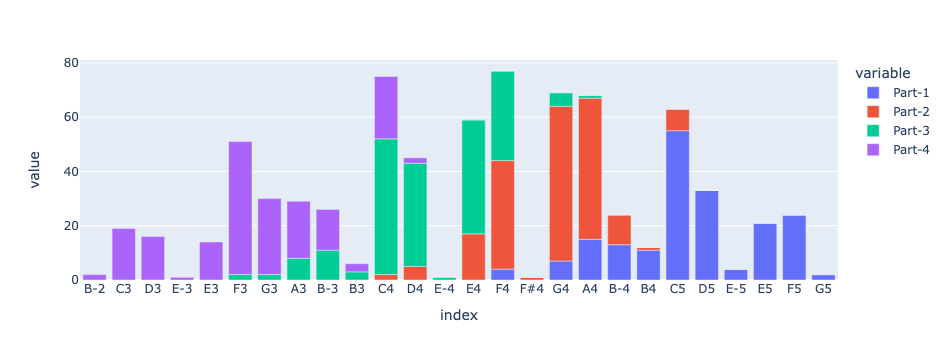

In [22]:
nr_no_mdata = nr.drop(['Composer', 'Title', "Date", "Measure", "Beat"], axis=1)
nr_counts = nr_no_mdata.apply(lambda x: x.value_counts(), axis=0).fillna('0').astype(int)
nr_counts.index = pd.CategoricalIndex(nr_counts.index, categories=pitch_order, ordered=True)
nr_counts = nr_counts.sort_index()
nr_counts = nr_counts.drop(index='Rest')
nr_counts = nr_counts[nr_counts.index.notnull()]
voices = nr_counts.columns.to_list()
# Creating the bar chart
fig = px.bar(nr_counts, x=nr_counts.index, y=list(nr_counts.columns),
             labels={col: col for col in nr_counts.columns})
fig
# # # # Show results
# nr_chart = px.bar(nr_counts, x='pitch', y=voices, title="Distribution of Pitches in " + piece.metadata['title'])
# nr_chart
# sorted_df
# nr_counts

In [23]:
voices

['Part-1', 'Part-2', 'Part-3', 'Part-4']

## All About Notes and Rests

Learn more here: https://github.com/HCDigitalScholarship/intervals/blob/rich_dev_22/tutorial/02_NotesAndRests.md

In [24]:
piece

In [14]:
test = piece.melodic()
test

,Primo Violino,Secondo Violino,Violone
0.00,Rest,Rest,Rest
0.75,NaN,-P4,NaN
1.00,NaN,m2,NaN
1.50,NaN,M2,NaN
1.75,NaN,-M2,NaN
...,...,...,...
324.50,NaN,m2,NaN
324.75,NaN,-m2,NaN
325.00,-m2,P1,NaN
325.50,-M2,-M2,NaN


In [15]:
ngs = piece.ngrams(n=4)
ngs

,Violone_Secondo Violino,Violone_Primo Violino,Secondo Violino_Primo Violino
8.50,NaN,NaN,"8_Held, 5_1, 6_1, 7"
8.75,NaN,NaN,"5_1, 6_1, 7_Held, 6"
9.00,NaN,NaN,"6_1, 7_Held, 6_-2, 6"
9.50,NaN,NaN,"7_Held, 6_-2, 6_2, 3"
9.75,NaN,NaN,"6_-2, 6_2, 3_2, 3"
...,...,...,...
323.50,"7_Held, 6_Held, 5_Held, 6",NaN,"5_-2, 6_-2, 7_2, 6"
323.75,"6_Held, 5_Held, 6_Held, 5",NaN,"6_-2, 7_2, 6_-2, 7"
324.00,"5_Held, 6_Held, 5_Held, 5",NaN,"7_2, 6_-2, 7_1, 6"
324.50,"6_Held, 5_Held, 5_Held, 4",NaN,"6_-2, 7_1, 6_-2, 6"


In [16]:
piece.cadences()

,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
40.0,Clausula Vera,1,TC,D3,P5,D,P5,4/4,11.0,1.0,3,0.122699,40.0,20.0
60.0,Evaded Clausula Vera,1,tC,G2,P1,G,P8,4/4,16.0,1.0,3,0.184049,20.0,30.0
90.0,Abandoned Authentic,1,Cx,E4,M13,C,P4,4/4,23.0,3.0,2,0.276074,30.0,104.0
194.0,Authentic,1,TCB,C3,P4,C,P4,3/2,46.0,1.0,3,0.595092,104.0,24.0
218.0,Clausula Vera,1,TC,G2,P1,G,P8,4/4,50.0,1.0,3,0.668712,24.0,16.0
234.0,Clausula Vera,1,TC,D3,P5,D,P5,4/4,54.0,1.0,3,0.717791,16.0,4.0
238.0,Clausula Vera,1,TC,G2,P1,G,P8,4/4,55.0,1.0,3,0.730061,4.0,20.0
258.0,Evaded Clausula Vera,1,tC,B-2,m3,B-,m3,4/4,60.0,1.0,3,0.791411,20.0,8.0
266.0,Authentic,1,TCB,D2,-P4,D,P5,4/4,62.0,1.0,3,0.815951,8.0,24.0


### C.3  Count, Sort and Graph Notes

* The Pandas library includes a vast array of standard methods for working with data frames (renaming columns, sorting data, counting categories, etc).  You can read just a few of the basic ones here:  **https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf**

* Using our dataframe of notes+rests (**`nr`**), you can experiment with a few (try them out below):

    * **count the number of rows** (which tells us simply how large the dataframe is):  
>`nr.count`

    * **rename a columns**:  
>`nr.rename(columns = {'[Superius]':'Cantus'})`

    * **stack all the columns** on top of each other to get one list of all the notes:  
>`nr.stack()`

    * **stack and count the number of unique values** (which will tell us how many different tones are in this piece):
>`nr.stack().nunique()`

    * **count the number of each note in each part**:  
>`nr.apply(pd.Series.value_counts).fillna(0).astype(int)`

    * **count and sort** the number of notes in a single voice part: 
    
>`nr.apply(pd.Series.value_counts).fillna(0).astype(int).sort_values(by=nr.columns[0], ascending=False)`
    
* This sorts by the first voice in the score.  If you want to sort by the last, then use `by=nr.columns[-1]` in he request.



,pitch,Alto,Basso,Partitura
15,F2,0,10,19
18,G2,0,12,12
1,A2,0,10,10
3,B-2,0,21,21
5,B2,0,1,1
7,C3,0,17,19
9,D3,0,17,17
11,E-3,0,1,1
13,E3,0,5,5
16,F3,5,25,15


/Users/rfreedma/anaconda3/envs/My_Intervals_Env/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



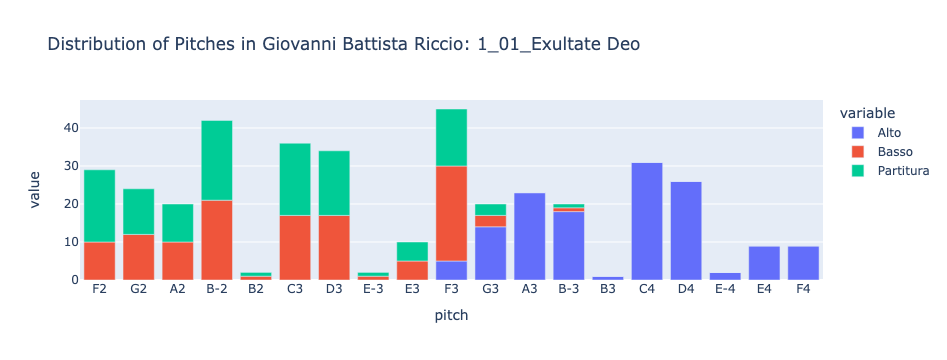

In [15]:
# set parameters
combineUnisons = True
combineRests = True
# new pitch table
pitch_order = ['E-2', 'E2', 'F2', 'F#2', 'G2', 'A2', 'B-2', 'B2', 
               'C3', 'C#3', 'D3', 'E-3','E3', 'F3', 'F#3', 'G3', 'G#3','A3', 'B-3','B3',
               'C4', 'C#4','D4', 'E-4', 'E4', 'F4', 'F#4','G4', 'A4', 'B-4', 'B4',
               'C5', 'C#5','D5', 'E-5','E5', 'F5', 'F#5', 'G5', 'A5', 'B-5', 'B5']

nr = piece.notes(combineUnisons ='combineUnisons', combineRests = 'combineRests').fillna('-')  
nr = nr.apply(pd.Series.value_counts).fillna(0).astype(int).reset_index().copy()  
nr.rename(columns = {'index':'pitch'}, inplace = True)  
nr['pitch'] = pd.Categorical(nr["pitch"], categories=pitch_order)  
nr = nr.sort_values(by = "pitch").dropna().copy()  
voices = nr.columns.to_list() 
display(nr)
px.bar(nr, x="pitch", y=voices, title="Distribution of Pitches in " + piece.metadata['composer'] + ": " + piece.metadata['title'])

### C. 3 Durations and Time Signatures
* We can use **`piece.durations()`** to tell us more about rhythms, and then combine the two dataframes into a synoptic view of the pitches and durations of the given piece.  Again, it is helpful to define this request as as variable that we can use later: **`dur = piece.durations().fillna('-')`**
<br>
* And of course we could **apply any of the tools noted above**, counting, sorting, etc, as needed.

* **Time Signatures** display each change of time signature with `piece.timeSignatures()`.  
* To see the **measure/beat index**, pass this to `piece.detailIndex()`:

>`ts = piece.timeSignatures()
piece.detailIndex(ts)`

In [16]:
ts = piece.timeSignatures()

det = piece.detailIndex(ts).reset_index()

det


/Users/rfreedma/anaconda3/envs/My_Intervals_Env/lib/python3.10/site-packages/crim_intervals/main_objs.py:851: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Measure,Beat,Alto,Basso,Partitura
0,1.0,1.0,4/4,4/4,4/4


In [17]:
piece.presentationTypes(limit_to_entries = True,
                        head_flex=1,
                        body_flex = 0,
                        include_hidden_types = True,
                        combine_unisons = True,
                        melodic_ngram_length = 4)

,Composer,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Presentation_Type,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Progress
0,Giovanni Battista Riccio,1_01_Exultate Deo,107.0,"[27.0/4.0, 28.0/2.0, 29.0/2.0]","[P-8, P11]","[107.0, 109.0, 113.0]","[(2, 2, -2, 2)]","[2.0, 4.0]","[Alto, Basso, Alto]",FUGA,3,False,False,None,0.5350
1,Giovanni Battista Riccio,1_01_Exultate Deo,146.5,"[37.0/3.5, 38.0/3.5]",[P-8],"[146.5, 150.5]","[(-3, 2, 2, 2)]",[4.0],"[Alto, Basso]",FUGA,2,False,False,None,0.7325


In [18]:
# piece.verovioCadences()
# piece.verovioHomorhythm()
piece.verovioPtypes()

Results:
File Name:  Riccio_1_01_Exultate_Deo_2vv
Giovanni Battista Riccio
1_01_Exultate Deo
Measures: 1-2
Presentation Type:  FUGA
Voices:  ['Basso', 'Alto']
Number of Entries:  2
Soggetti:  [('-2', '-2', '1', '-2')]
Melodic Entry Intervals:  ['P5']
Time Entry Intervals:  [4.0]
Flexed:  False
Parallel Entries: Partitura
Number of Non-Overlapping Voices: 0


File Name:  Riccio_1_01_Exultate_Deo_2vv
Giovanni Battista Riccio
1_01_Exultate Deo
Measures: 27-29
Presentation Type:  FUGA
Voices:  ['Alto', 'Basso', 'Alto']
Number of Entries:  3
Soggetti:  [('2', '2', '-2', '2')]
Melodic Entry Intervals:  ['P-8', 'P11']
Time Entry Intervals:  [2.0, 4.0]
Flexed:  False
Parallel Entries: None
Number of Non-Overlapping Voices: 0


File Name:  Riccio_1_01_Exultate_Deo_2vv
Giovanni Battista Riccio
1_01_Exultate Deo
Measures: 37-38
Presentation Type:  FUGA
Voices:  ['Alto', 'Basso']
Number of Entries:  2
Soggetti:  [('-3', '2', '2', '2')]
Melodic Entry Intervals:  ['P-8']
Time Entry Intervals:  [4.0]
Flexed:  False
Parallel Entries: None
Number of Non-Overlapping Voices: 0


In [19]:
piece.verovioPrintExample(1, -1)

Score:
File Name:  Riccio_1_01_Exultate_Deo_2vv
Giovanni Battista Riccio
1_01_Exultate Deo
Measures: 1-51


File Name:  Riccio_1_01_Exultate_Deo_2vv
Giovanni Battista Riccio
1_01_Exultate Deo
Measures: 1-51


File Name:  Riccio_1_01_Exultate_Deo_2vv
Giovanni Battista Riccio
1_01_Exultate Deo
Measures: 1-51


In [47]:

import glob as glob
corpus_list = sorted(glob.glob('Music_Files/*'))
corpus_list

['Music_Files/CRIM_Model_0001.mei',
 'Music_Files/CRIM_Model_0008.mei',
 'Music_Files/Riccio_1_34_Canzon_[I]_2vv.musicxml',
 'Music_Files/Riccio_1_35_Canzon_a_doi_flautini_[I]_2vv.musicxml']

In [48]:
for name in corpus_list:
    piece = importScore(name)
    piece.verovioPrintExample(1, 2)

Score:
File Name:  CRIM_Model_0001
Lupi, Johannes
Vidi speciosam
Measures: 1-2


[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>


Score:
File Name:  CRIM_Model_0008
Josquin Des Prés
Ave Maria
Measures: 1-2


[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported data.PERCENT '100'
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] Unsupported '<line>' within <measure>
[Warning] 4 time pointing element(s) could not be matched in measure m-4149
[Warning] 4 time pointing element(s) could not be matched in measure m-4132
[Warning] 4 time pointing element(s) could not be matched in measure m-4098


Score:
File Name:  Riccio_1_34_Canzon_[I]_2vv
Giovanni Battista Riccio
1_34_Canzon [I]
Measures: 1-2


Score:
File Name:  Riccio_1_35_Canzon_a_doi_flautini_[I]_2vv
Giovanni Battista Riccio
1_35_Canzon [II]
Measures: 1-2


In [22]:
piece.cadenceRadarPlot(combinedType = True, displayAll = True, renderer = "iframe")

ValueError: Columns must be same length as key

In [23]:
piece.cadences()

ValueError: Columns must be same length as key

In [21]:
piece.cadenceProgressPlot(includeType = True)


ValueError: Columns must be same length as key

In [ ]:
# find entries for model
n = 4
kind = 'd'
combineUnsions = True

nr = piece.notes(combineUnisons=combineUnsions)
mel = piece.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = piece.ngrams(df=mel, n=n)
mod_entry_ngrams = piece.entries(df=mel, n=n, thematic=True, anywhere=True)
mod_mel_ngrams_duration = piece.durations(df=mel, n=n, mask_df=mod_entry_ngrams)
mod_entries_stack = list(mod_entry_ngrams.stack().unique())

print(piece.metadata)

display(viz.plot_ngrams_heatmap(mod_entry_ngrams, mod_mel_ngrams_duration, 
                        selected_patterns=mod_entries_stack,
                        voices=[]))

In [ ]:
dur = piece.durations().fillna('-')
dur

### C.4 Combining Notes and Durations in a Single Data Frame

* Two or more data frames can be combined into one. Here we can combine **`nr`** (our Notes and Rests) with **`dur`** to make a single data frame.  This frame can it self be given a new name:  

>`combined_notes_durs = pd.concat([nr, dur], axis=1)`


In [ ]:
nr = piece.notes()
dur = piece.durations()
combined_notes_durs = pd.concat([nr, dur], axis=1).fillna('-')
combined_notes_durs.head()

* We can also reorder the columns to put the information for each voice together.  Here we will use Pandas **iloc**, which is a way to refer to row or column by it's **index** number.  

* In Pandas the first row (or column) is **`0`**.  So to see just the notes_rests and durations for the Superius:
>`combined_notes_durs.iloc[:, [0, 4]]`

* To see all the voices reorganized in this way:  

>`combined_notes_durs.iloc[:, [0, 4, 1, 5, 2, 6, 3, 7]]`

In [ ]:
combined_notes_durs.iloc[:, [0, 4, 1, 5, 2, 6, 3, 7]]

### C.5 Measures and Beats

* Music21(and therefore CRIM Intervals) measures time according to **offsets** (one offset = one quarter note). The very first offset in any piece is **0**. 

* Of course human readers will prefer identifying locations by **measure + beat addresses**
<br>

* To do this we 'pass' a name representing the first set of results **`combined_notes_durs`** to another method, **`detailIndex`**.  Thus:

>`piece.detailIndex(combined_notes_durs)`

* if you also would like to see the offsets, we include an additional "argument" in the parentheses: 

>` piece.detailIndex(combined_notes_durs, offset=True`

In [ ]:
meas_beat = piece.detailIndex(combined_notes_durs)
meas_beat
